In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train = pd.read_csv(r"C:\analytics portfolio\machine-learning-projects\sales-forecasting-ml\data\train.csv")
features = pd.read_csv(r"C:\analytics portfolio\machine-learning-projects\sales-forecasting-ml\data\features.csv")
stores = pd.read_csv(r"C:\analytics portfolio\machine-learning-projects\sales-forecasting-ml\data\stores.csv")


print(features.shape)
print(stores.shape)
print(train.shape)

train.head()

(8190, 12)
(45, 3)
(421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05-02-2010,24924.50,False
1,1,1,12-02-2010,46039.49,True
2,1,1,19-02-2010,41595.55,False
3,1,1,26-02-2010,19403.54,False
4,1,1,05-03-2010,21827.90,False


In [3]:
# Merge datasets
data = train.merge(features, on=['Store', 'Date'], how='left')
data = data.merge(stores, on='Store', how='left')

print(data.shape)
data.head()

(421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,05-02-2010,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,12-02-2010,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,19-02-2010,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,26-02-2010,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,05-03-2010,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [5]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [6]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['Week'] = data['Date'].dt.isocalendar().week
data['DayOfWeek'] = data['Date'].dt.dayofweek

In [7]:
data[['Date','Year','Month','Day','Week','DayOfWeek']].head()

,Date,Year,Month,Day,Week,DayOfWeek
0,2010-02-05,2010,2,5,5,4
1,2010-02-12,2010,2,12,6,4
2,2010-02-19,2010,2,19,7,4
3,2010-02-26,2010,2,26,8,4
4,2010-03-05,2010,3,5,9,4


In [8]:
# Sort data first
data = data.sort_values(by=['Store', 'Date'])

# Lag features
data['Lag_1'] = data.groupby('Store')['Weekly_Sales'].shift(1)
data['Lag_2'] = data.groupby('Store')['Weekly_Sales'].shift(2)
data['Lag_4'] = data.groupby('Store')['Weekly_Sales'].shift(4)
data['Lag_8'] = data.groupby('Store')['Weekly_Sales'].shift(8)

In [9]:
# Rolling mean
data['Rolling_Mean_4'] = data.groupby('Store')['Weekly_Sales'].shift(1).rolling(4).mean()
data['Rolling_Mean_8'] = data.groupby('Store')['Weekly_Sales'].shift(1).rolling(8).mean()

In [10]:
data = data.dropna()

In [11]:
data.shape
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Month,Day,Week,DayOfWeek,Lag_1,Lag_2,Lag_4,Lag_8,Rolling_Mean_4,Rolling_Mean_8
92,1,1,2011-11-11,18689.54,False,59.11,3.297,10382.9,6115.67,215.07,...,11,11,45,4,13026.08,36482.93,114793.92,62223.17,49402.5825,68711.33500
235,1,2,2011-11-11,44936.47,False,59.11,3.297,10382.9,6115.67,215.07,...,11,11,45,4,18689.54,13026.08,33307.40,152401.64,25376.4875,63269.63125
378,1,3,2011-11-11,9959.64,False,59.11,3.297,10382.9,6115.67,215.07,...,11,11,45,4,44936.47,18689.54,36482.93,77943.57,28283.7550,49836.48500
521,1,4,2011-11-11,36826.52,False,59.11,3.297,10382.9,6115.67,215.07,...,11,11,45,4,9959.64,44936.47,13026.08,59511.97,21652.9325,41338.49375
664,1,5,2011-11-11,31002.65,False,59.11,3.297,10382.9,6115.67,215.07,...,11,11,45,4,36826.52,9959.64,18689.54,114793.92,27603.0425,38502.81250


In [16]:
# Convert categorical columns to numbers
data = pd.get_dummies(data, drop_first=True)

In [19]:
X = data.drop(['Weekly_Sales', 'Date'], axis=1)
y = data['Weekly_Sales']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4622.411480774778
RMSE: 8960.46245960798
R2 Score: 0.8183058471937518


In [24]:
import joblib

joblib.dump(model, '../models/sales_forecast_model.pkl')

['../models/sales_forecast_model.pkl']

In [25]:
# Get last data for each store
last_data = data.groupby('Store').tail(1)

future_data = last_data.copy()

In [26]:
future_data['Predicted_Sales'] = model.predict(
    future_data.drop(['Weekly_Sales', 'Date'], axis=1)
)

future_data[['Store', 'Predicted_Sales']].head()

,Store,Predicted_Sales
10206,1,12409.3377
20439,2,13700.7140
29481,3,629.7214
39743,4,15529.2717
48760,5,665.2242


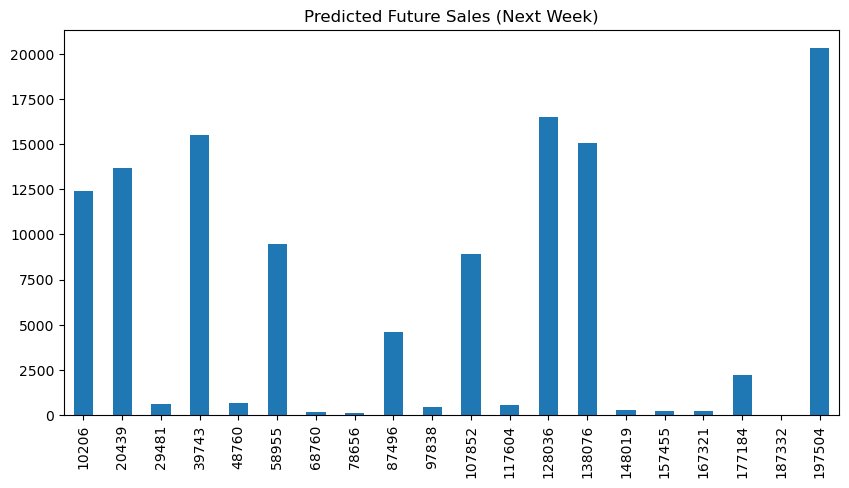

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
future_data['Predicted_Sales'].head(20).plot(kind='bar')
plt.title("Predicted Future Sales (Next Week)")
plt.show()

In [28]:
plt.savefig('../visuals/future_sales.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [31]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [32]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 12465.6130393732
RMSE: 19051.77303765269
R2: 0.17860718381241392


In [33]:
print("Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R2:", r2_score(y_test, gb_pred))

Gradient Boosting
MAE: 6884.654436271792
RMSE: 10059.106781337814
R2: 0.7710192683616592


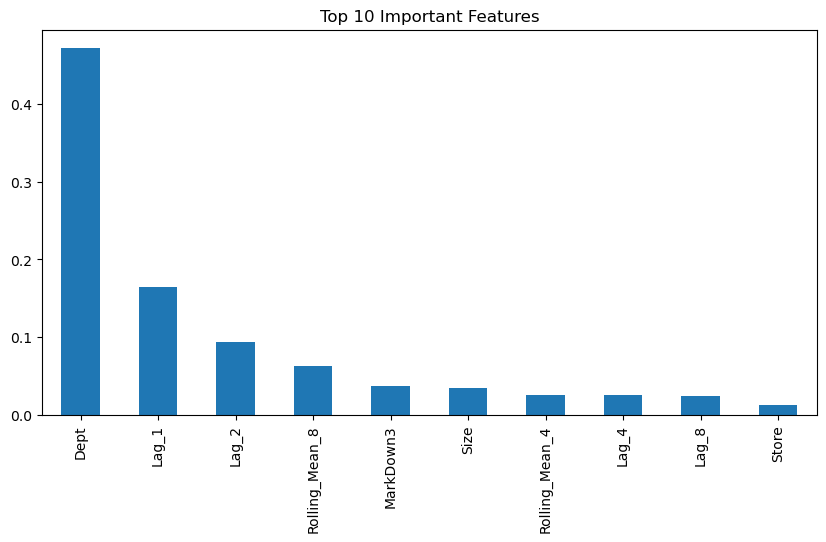

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")

plt.savefig('../visuals/feature_importance.png')
plt.show()

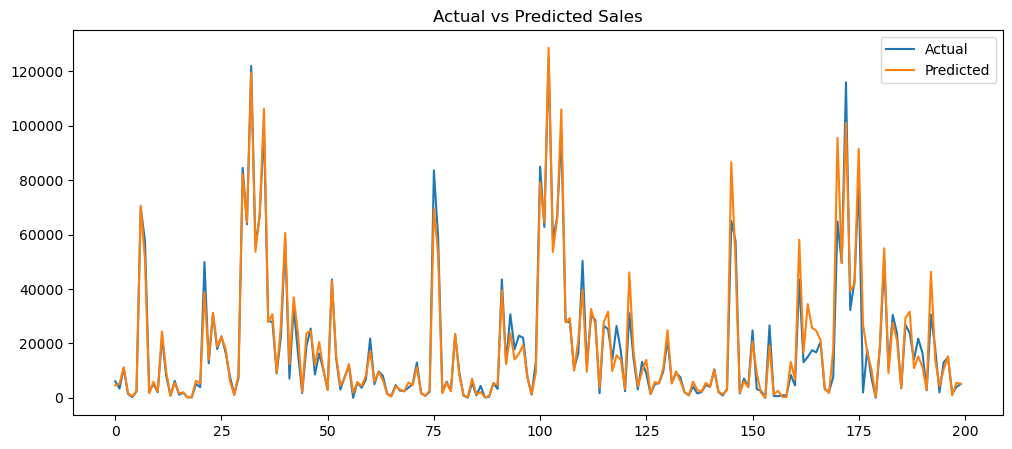

In [35]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")

plt.savefig('../visuals/actual_vs_predicted.png')
plt.show()

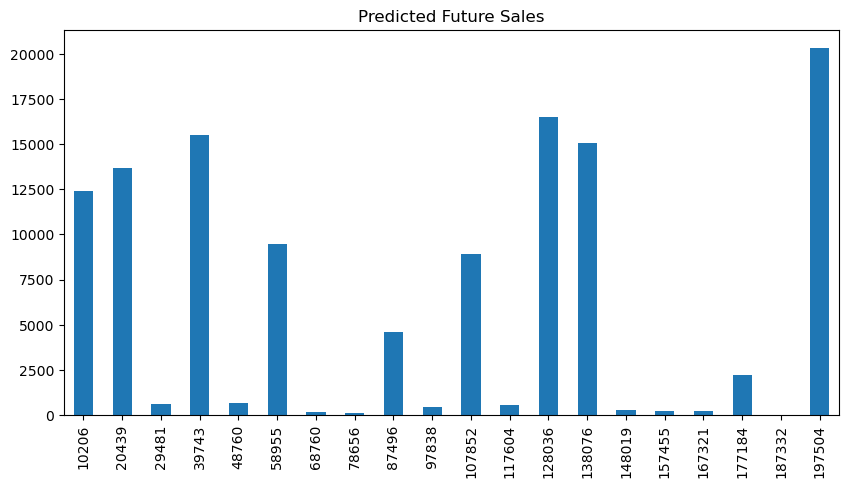

In [36]:
plt.figure(figsize=(10,5))
future_data['Predicted_Sales'].head(20).plot(kind='bar')
plt.title("Predicted Future Sales")

plt.savefig('../visuals/future_sales.png')
plt.show()

In [37]:
# Save feature columns
joblib.dump(X.columns, '../models/model_columns.pkl')

['../models/model_columns.pkl']